# Parameterized PINN — Unconfined Aquifer (Single Well)
**Architecture**: Q concatenated as 4th input (x, y, t, Q_norm) — follows paper directly  
**Q range**: [-50000, -25000] m³/day (2× range, Q=-40000 sits inside)  
Run this notebook on a **T4 GPU** runtime (Runtime → Change runtime type → T4 GPU)

## 1. Mount Google Drive

In [7]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os

DRIVE_CODE = '/content/drive/MyDrive/para_pinns/param_pinn'
os.chdir(DRIVE_CODE)
sys.path.insert(0, DRIVE_CODE)

print('Working directory:', os.getcwd())
print('Files:', os.listdir('.'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/para_pinns/param_pinn
Files: ['mf2005.exe', 'mf6.exe', 'modflow', 'sampler.py', 'dataset.py', 'utils.py', 'data', 'problem.py', '__pycache__', 'runs', 'checkpoints', 'model.py', 'train.py', 'options.py', 'run.sh', 'trainer.py', 'train_colab.html', 'sensitivity_test.py', 'sensitivity_plots', 'llm_interface_wrapper', 'input.json', 'presentation_prompt.md', 'train_colab.ipynb', 'generate.py']


## 2. Install dependencies

In [ ]:
!pip install -q tensorboardX pyDOE scipy "numpy<2.0"
print('Dependencies installed.')

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 68.3/68.3 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 84.0 MB/s eta 0:00:00


## 3. GPU check

In [8]:
import torch
print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: No GPU — go to Runtime → Change runtime type → T4 GPU')

PyTorch: 2.10.0+cu128
GPU: Tesla T4
VRAM: 15.6 GB


## 4. Sanity check — model loads and forward pass works

In [9]:
import sys
os.chdir(DRIVE_CODE)
sys.path.insert(0, DRIVE_CODE)

sys.argv = ['train']

from options import Options
from problem import Problem
from model import Net
import torch

args = Options().parse()
args.Q_min = -50000.0
args.Q_max = -25000.0
args.hidden_layers = 5
args.hidden_neurons = 50
args.layers = [4] + args.hidden_layers * [args.hidden_neurons] + [1]
args.sigma = 30.0
args.problem = Problem(sigma=args.sigma)
args.constraint = 'HARD'
args.tau = 1.0
args.stage = 1

net = Net(args, stage=1)
total = sum(p.numel() for p in net.parameters())
print(f'Total parameters: {total:,}')

xyt = torch.randn(100, 3)
h = net(xyt, Q_norm=0.0)
print(f'Output shape: {h.shape}  — PASSED')

Total parameters: 10,751
Output shape: torch.Size([100, 1])  — PASSED


## 5. Stage 1 Training  (t = 0 → 1 day)
Trains the network on the early transient period.  
**Expected time on T4 GPU: ~15–25 min**

In [ ]:
os.chdir(DRIVE_CODE)
!python train.py \
  --stage 1 \
  --constraint HARD \
  --tau 1 \
  --sigma 30 \
  --hidden_layers 5 \
  --hidden_neurons 50 \
  --Q_min -50000 \
  --Q_max -25000 \
  --spatial_strategy LR \
  --temporal_strategy LHS \
  --nt 100 \
  --lam 100 \
  --lr 0.001 \
  --epochs_Adam 5000

## 6. Stage 2 Training  (t = 1 → 30 days)
Loads Stage 1 checkpoint, trains on the long-term transient period.  
**Expected time on T4 GPU: ~60–90 min**

In [ ]:
os.chdir(DRIVE_CODE)
!python train.py \
  --stage 2 \
  --constraint HARD \
  --tau 1 \
  --sigma 30 \
  --hidden_layers 5 \
  --hidden_neurons 50 \
  --Q_min -50000 \
  --Q_max -25000 \
  --spatial_strategy LR \
  --temporal_strategy LHS \
  --temporal_strategy_prev LHS \
  --nt 100 \
  --nt_prev 100 \
  --lam 100 \
  --lr 0.001 \
  --epochs_Adam 5000

In [ ]:
!pip install -q "numpy<2.0"

## 8. (Optional) Resume training if Colab disconnected
Copy checkpoints back from Drive, then resume from the best checkpoint.

In [ ]:
# Run this cell ONLY if you need to resume after a disconnect
# 1. Re-mount Drive and copy code + checkpoints back
from google.colab import drive
drive.mount('/content/drive')

import shutil, os
DRIVE_CODE = '/content/drive/MyDrive/para_pinns/param_pinn'
LOCAL_CODE = '/content/param_pinn'

if os.path.exists(LOCAL_CODE):
    shutil.rmtree(LOCAL_CODE)
shutil.copytree(DRIVE_CODE, LOCAL_CODE)

# Verify checkpoints are present
ckpt_dir = os.path.join(LOCAL_CODE, 'checkpoints')
print('Available checkpoints:')
for d in os.listdir(ckpt_dir):
    files = os.listdir(os.path.join(ckpt_dir, d))
    print(f'  {d}: {files}')

print('\nNow re-run Stage 2 training cell with --resume pointing to checkpoint.pth.tar')

In [ ]:
# Run this cell ONLY if you need to resume after a disconnect
# Drive is already mounted — just re-run cell 2 to restore DRIVE_CODE, then re-run training cells.

from google.colab import drive
drive.mount('/content/drive')

import sys, os
DRIVE_CODE = '/content/drive/MyDrive/para_pinns/param_pinn'
os.chdir(DRIVE_CODE)
sys.path.insert(0, DRIVE_CODE)

ckpt_dir = os.path.join(DRIVE_CODE, 'checkpoints')
print('Available checkpoints:')
for d in os.listdir(ckpt_dir):
    files = os.listdir(os.path.join(ckpt_dir, d))
    print(f'  {d}: {files}')

## 9. Sensitivity Analysis — Percentage Changes from Baseline Q
Tests the trained model at percentage deviations from baseline Q = −40,000 m³/day.
All Q values fall within the training range [−50,000, −25,000].
**No retraining needed — uses the existing Stage 2 checkpoint.**

In [ ]:
%matplotlib inline
os.chdir(DRIVE_CODE)
!python sensitivity_test.py

Stage 1 checkpoint: checkpoints/Stage1_HARD_5x50_tau:1_sigma:30_S:LR_T:LHS_nt:100/best_model.pth.tar
Stage 2 checkpoint: checkpoints/Stage2_HARD_5x50_tau:1_sigma:30_S:LR_T:LHS_nt:100/best_model.pth.tar
Stage 1 loaded.
Stage 2 loaded.

Sensitivity Analysis — Parameterized GW-PINN
Baseline Q = -40,000 m³/day   |   evaluated at t = 30 days
Training range: [-50,000, -25,000] m³/day

  % Change        Q (m³/d)    max |Δh| (m)    mean Δh (m)    max drawdown (m)
---------------------------------------------------------------------------
       -25%         -30,000          1.7461         0.3974              5.2371
       -10%         -36,000          0.7100         0.1616              6.2731
        -5%         -38,000          0.3561         0.0809              6.6271
        +0%         -40,000          0.0000         0.0000              6.9832  <- baseline
        +5%         -42,000          0.3576        -0.0805              7.3408
       +10%         -44,000          0.7165        -0.16

sensitivity_dh_maps.png


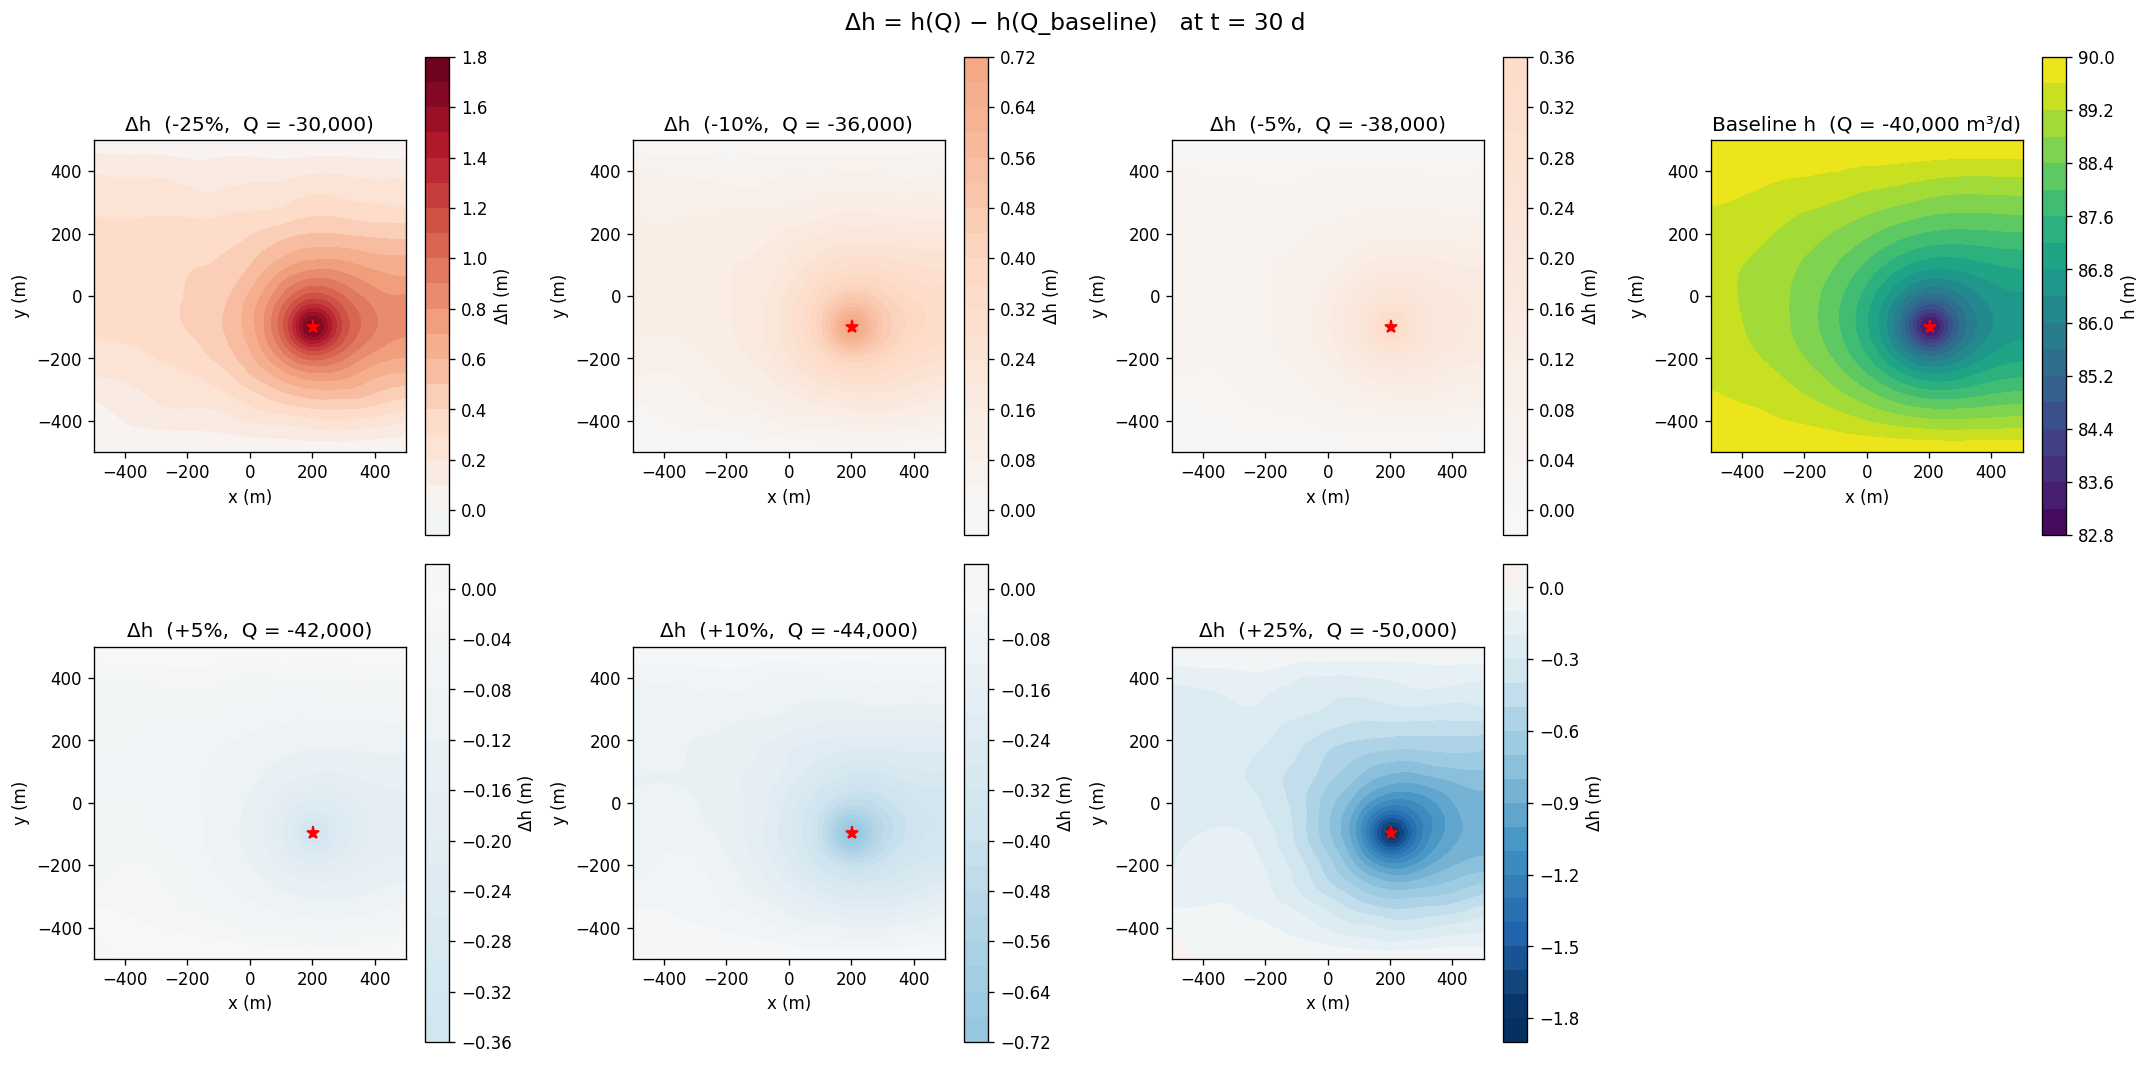

sensitivity_summary.png


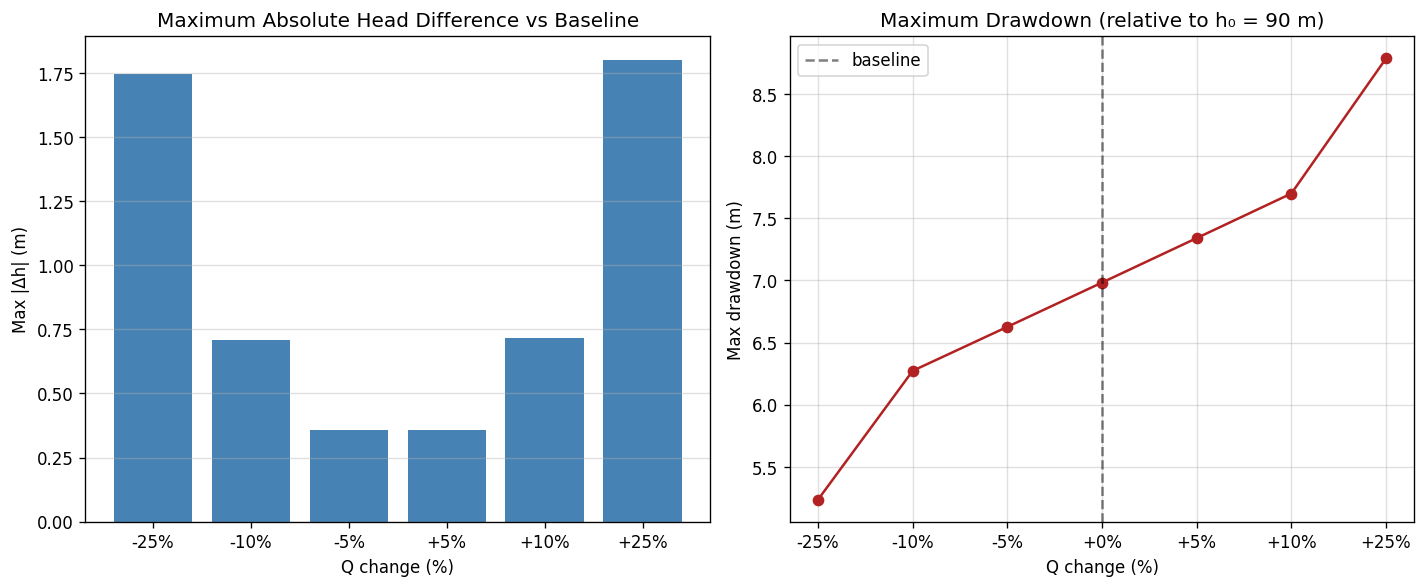

In [ ]:
from IPython.display import Image, display
import os
for fname in ["sensitivity_dh_maps.png", "sensitivity_summary.png"]:
    fpath = os.path.join(DRIVE_CODE, "sensitivity_plots", fname)
    if os.path.exists(fpath):
        print(fname)
        display(Image(fpath))
    else:
        print(f"Not found: {fpath} — run the cell above first")


In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('./modflow/Q-40000/t30.txt',
                 sep=r'\s*,\s*|\s+',
                 engine='python',
                 header=None,
                 names=['x','y','h'])

print("Total rows:", len(df))
print("Unique x:", len(df['x'].unique()))
print("Unique y:", len(df['y'].unique()))

print("Min x, Max x:", df['x'].min(), df['x'].max())
print("Min y, Max y:", df['y'].min(), df['y'].max())

# Check spacing
x_sorted = np.sort(df['x'].unique())
y_sorted = np.sort(df['y'].unique())

print("Δx (first few):", np.round(np.diff(x_sorted)[:5], 4))
print("Δy (first few):", np.round(np.diff(y_sorted)[:5], 4))

Total rows: 90000
Unique x: 300
Unique y: 300
Min x, Max x: 1.6667 998.3333
Min y, Max y: 1.6667 998.3333
Δx (first few): [3.3333 3.3333 3.3334 3.3333 3.3333]
Δy (first few): [3.3333 3.3333 3.3334 3.3333 3.3333]


In [10]:
# ============================================================
# Setup: load two-stage model + shared grid for checks below
# ============================================================
import sys, os, copy
import numpy as np
import torch

os.chdir(DRIVE_CODE)
sys.path.insert(0, DRIVE_CODE)
sys.argv = ["train"]

from options import Options
from problem import Problem
from model import Net, PINN

def _normalize_Q(Q, Q_min, Q_max):
    return 2.0 * (Q - Q_min) / (Q_max - Q_min) - 1.0

# -- Config (must match training) --
base_args = Options().parse()
base_args.hidden_layers          = 5
base_args.hidden_neurons         = 50
base_args.Q_min                  = -50000.0
base_args.Q_max                  = -25000.0
base_args.sigma                  = 30.0
base_args.tau                    = 1.0
base_args.constraint             = "HARD"
base_args.stage                  = 2
base_args.spatial_strategy       = "LR"
base_args.temporal_strategy      = "LHS"
base_args.temporal_strategy_prev = "LHS"
base_args.nt                     = 100
base_args.nt_prev                = 100
base_args.lam                    = 100
base_args.lr                     = 0.001
base_args.epochs_Adam            = 0
base_args.resume                 = None
base_args.layers = [4] + base_args.hidden_layers * [base_args.hidden_neurons] + [1]
base_args.problem = Problem(sigma=base_args.sigma)

device = base_args.device
_tau   = base_args.tau
_Qmin  = base_args.Q_min
_Qmax  = base_args.Q_max

_stem = (f"{base_args.constraint}_{base_args.hidden_layers}x{base_args.hidden_neurons}"
         f"_tau:{_tau:.0f}_sigma:{base_args.sigma:.0f}_S:{base_args.spatial_strategy}")
_ckpt1 = f"checkpoints/Stage1_{_stem}_T:{base_args.temporal_strategy_prev}_nt:{base_args.nt_prev}/best_model.pth.tar"
_ckpt2 = f"checkpoints/Stage2_{_stem}_T:{base_args.temporal_strategy}_nt:{base_args.nt}/best_model.pth.tar"

_args1 = copy.deepcopy(base_args); _args1.stage = 1
net1 = Net(_args1, stage=1)
PINN(net1).load_state_dict(torch.load(_ckpt1, map_location=device)["state_dict"])
net1.to(device); net1.eval()

_args2 = copy.deepcopy(base_args); _args2.stage = 2
net2 = Net(_args2, stage=2)
PINN(net2).load_state_dict(torch.load(_ckpt2, map_location=device)["state_dict"])
net2.to(device); net2.eval()

# Baseline Q = -40,000 m3/day
_Q_norm_base = _normalize_Q(-40000.0, _Qmin, _Qmax)

class TwoStageModel:
    """Callable wrapper: (N,3) xyt tensor -> (N,1) head. Supports .eval()."""
    def eval(self): net1.eval(); net2.eval(); return self
    def __call__(self, xyt_tensor):
        N = xyt_tensor.shape[0]
        xytau = torch.cat([
            xyt_tensor[:, :2],
            torch.full((N, 1), _tau, dtype=torch.float32, device=xyt_tensor.device)
        ], dim=1)
        with torch.no_grad():
            hstar = net1(xytau, _Q_norm_base)
            h     = net2(xyt_tensor, _Q_norm_base, hstar)
        return h

model = TwoStageModel()

# Shared grid variables used by cells below
nx, ny       = 300, 300
x_min, x_max = -500, 500
y_min, y_max = -500, 500
x_grid_sh    = np.linspace(x_min, x_max, nx)
y_grid_sh    = np.linspace(y_min, y_max, ny)
grid_x_sh, grid_y_sh = np.meshgrid(x_grid_sh, y_grid_sh)
xy_grid      = np.vstack([grid_x_sh.ravel(), grid_y_sh.ravel()]).T  # (N, 2)
xy_grid_val  = xy_grid   # alias used in PDE-residual and BC cells

print(f"Stage 1 loaded: {_ckpt1}")
print(f"Stage 2 loaded: {_ckpt2}")
print(f"Q_norm (baseline Q=-40000): {_Q_norm_base:.4f}")
print(f"Shared grid: {nx}x{ny}, x in [{x_min},{x_max}], y in [{y_min},{y_max}]")


Stage 1 loaded: checkpoints/Stage1_HARD_5x50_tau:1_sigma:30_S:LR_T:LHS_nt:100/best_model.pth.tar
Stage 2 loaded: checkpoints/Stage2_HARD_5x50_tau:1_sigma:30_S:LR_T:LHS_nt:100/best_model.pth.tar
Q_norm (baseline Q=-40000): -0.2000
Shared grid: 300x300, x in [-500,500], y in [-500,500]


FIGURE 3b: ROBUST ERROR MAPS (Clipped to 99th Percentile)
Found 33 time snapshots: [0.25, 0.5, 0.75, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0]
  t=  0.25 d | RMSE=0.2835 m | Max=7.9899 m
  t=  0.50 d | RMSE=0.1785 m | Max=8.6044 m
  t=  0.75 d | RMSE=0.1213 m | Max=8.9617 m
  t=  1.00 d | RMSE=0.1512 m | Max=8.8506 m
  t=  2.00 d | RMSE=0.2863 m | Max=9.8256 m
  t=  3.00 d | RMSE=0.3351 m | Max=9.9581 m
  t=  4.00 d | RMSE=0.3373 m | Max=9.9820 m
  t=  5.00 d | RMSE=0.3126 m | Max=9.9525 m
  t=  6.00 d | RMSE=0.2742 m | Max=9.8986 m
  t=  7.00 d | RMSE=0.2310 m | Max=9.8359 m
  t=  8.00 d | RMSE=0.1891 m | Max=9.7721 m
  t=  9.00 d | RMSE=0.1535 m | Max=9.7112 m
  t= 10.00 d | RMSE=0.1287 m | Max=9.6553 m
  t= 11.00 d | RMSE=0.1179 m | Max=9.6056 m
  t= 12.00 d | RMSE=0.1204 m | Max=9.5627 m
  t= 13.00 d | RMSE=0.1312 m | Max=9.5268 m
  t= 14.00 d | RMSE=0.14

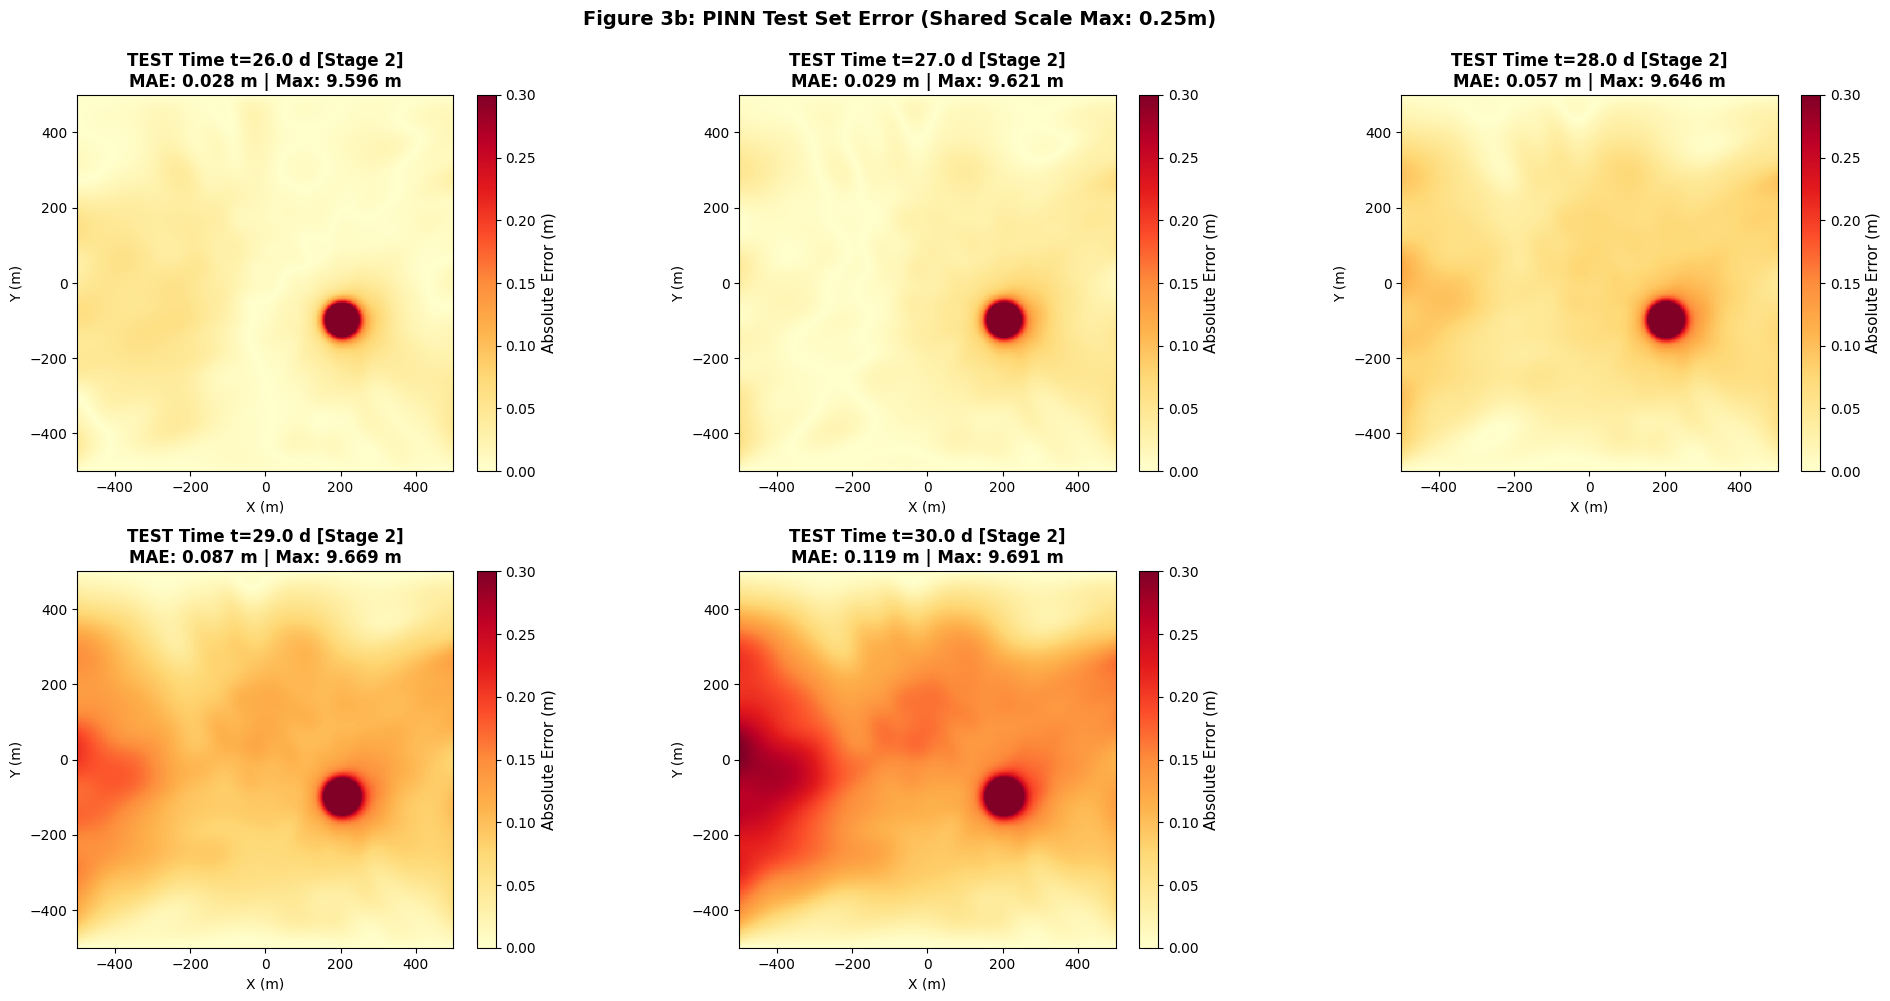

In [ ]:
import glob
import re
import pandas as pd
from scipy.interpolate import griddata
import matplotlib.pyplot as plt

model.eval()

print("=" * 80)
print("FIGURE 3b: ROBUST ERROR MAPS (Clipped to 99th Percentile)")
print("=" * 80)

# 1. Identify all available MODFLOW time files
pattern = "./modflow/t*.txt" # Corrected path
files = sorted(glob.glob(pattern))

def parse_time(f):
    m = re.search(r't([0-9]+(?:\.[0-9]+)?)', f)
    return float(m.group(1)) if m else None

# Collect ALL available time files (TwoStageModel handles stage routing)
time_files = []
for f in files:
    t_val = parse_time(f)
    if t_val is not None:
        time_files.append((t_val, f))

time_files.sort(key=lambda x: x[0])
times = [t for t, f in time_files]

print(f"Found {len(times)} time snapshots: {times}")

# # 2. Setup Grid (aligned with PINN domain [-500, 500])
# nx, ny = 300, 300
# x_min, x_max = -500, 500
# y_min, y_max = -500, 500
# x = np.linspace(x_min, x_max, nx)
# y = np.linspace(y_min, y_max, ny)
# grid_x, grid_y = np.meshgrid(x, y)
# xy_grid = np.vstack([grid_x.ravel(), grid_y.ravel()]).T  # (N, 2)

# 3. Compute RMSE for ALL timesteps to find max-error period
rmse_per_timestep = []
error_maps = {}  # Cache error maps to avoid re-computing

with torch.no_grad():
    for t_val, f_path in time_files:
        # A. Load MODFLOW Ground Truth
        try:
            df = pd.read_csv(f_path, sep=r'\s*,\s*|\s+', engine="python",
                             header=None, names=['x', 'y', 'h'])
            df = df.apply(pd.to_numeric, errors='coerce').dropna()

            # Shift MODFLOW coords to PINN domain (0..1000 -> -500..500)
            if df['x'].min() >= 0:
                points = df[['x', 'y']].values - 500.0
            else:
                points = df[['x', 'y']].values

            values = df['h'].values

            # Interpolate to grid
            # Get structured grid directly
            x_unique = np.sort(df['x'].unique())
            y_unique = np.sort(df['y'].unique())

            # Shift to PINN domain
            # x_unique = x_unique - 500
            # y_unique = y_unique - 500

            grid_x, grid_y = np.meshgrid(x_unique, y_unique)

            # Reshape directly (no interpolation)
            grid_h_true = df['h'].values.reshape(len(y_unique), len(x_unique))

            mask = np.ones_like(grid_h_true, dtype=bool)


        except Exception as e:
            print(f"Error loading {f_path}: {e}")
            rmse_per_timestep.append(0.0)
            continue

        # B. PINN Prediction — (x, y, t) input
        t_vec = np.full((xy_grid.shape[0], 1), t_val)
        xyt_input = np.hstack([xy_grid, t_vec])
        xyt_tensor = torch.from_numpy(xyt_input).float().to(device)

        h_pred_tensor = model(xyt_tensor)
        grid_h_pred = h_pred_tensor.cpu().numpy().reshape(ny, nx)

        # C. Compare (valid pixels only)
        diff = grid_h_pred[mask] - grid_h_true[mask]
        rmse = np.sqrt(np.mean(diff**2))
        rmse_per_timestep.append(rmse)

        full_diff = np.abs(grid_h_pred - grid_h_true)
        error_maps[t_val] = full_diff

        print(f"  t={t_val:6.2f} d | RMSE={rmse:.4f} m | Max={np.nanmax(full_diff):.4f} m")

rmse_per_timestep = np.array(rmse_per_timestep)

# ============================================================================
# Figure 3b: Robust Spatial Error Map (TEST SET ONLY: LAST 5 SNAPSHOTS)
# ============================================================================
# ... [Sections 1, 2, and 3 remain the same as your provided code] ...

rmse_per_timestep = np.array(rmse_per_timestep)

# 4. Select Indices (EXCLUSIVELY THE LAST 5 SNAPSHOTS - TEST SET)
num_test_snapshots = 5

if len(times) < num_test_snapshots:
    print(f"Warning: Only found {len(times)} snapshots. Plotting all available.")
    selected_indices = list(range(len(times)))
else:
    # Explicitly take the last 5 indices
    selected_indices = list(range(len(times) - num_test_snapshots, len(times)))

print(f"Evaluating Test Set indices: {selected_indices}")
print(f"Test Set times: {[times[i] for i in selected_indices]} days")

# Collect valid errors for Robust Scaling (99th percentile) across the TEST SET
all_valid_errors = []
plot_data = []

for idx in selected_indices:
    t_val = times[idx]
    err_map = error_maps[t_val]
    valid_errs = err_map[~np.isnan(err_map)]
    all_valid_errors.append(valid_errs)
    plot_data.append((t_val, err_map))

all_valid_errors_flat = np.concatenate(all_valid_errors)

# Calculate Robust Scale based on the Test Set distribution
vmax_robust = np.percentile(all_valid_errors_flat, 99)
max_real = np.max(all_valid_errors_flat)

print(f"\nTEST SET STATISTICS:")
print(f"True Maximum Error:   {max_real:.4f} m")
print(f"99th Percentile Cap:  {vmax_robust:.4f} m")

# Plot (Adjusting to a 1x5 or 2x3 layout since we have 5 snapshots)
fig = plt.figure(figsize=(20, 10))

for plot_idx, (t_val, abs_error) in enumerate(plot_data):
    # Using a 2x3 grid to accommodate 5 snapshots
    ax = fig.add_subplot(2, 3, plot_idx + 1)

    im = ax.imshow(abs_error, cmap='YlOrRd', interpolation='nearest',
                   extent=[x_min, x_max, y_min, y_max], origin='lower',
                   vmin=0, vmax=0.30) ###adjust the max for the plots for fairness!!!

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label('Absolute Error (m)', fontsize=11)

    valid_mask = ~np.isnan(abs_error)
    mae_val = np.mean(abs_error[valid_mask])
    local_max = np.max(abs_error[valid_mask])

    ax.set_title(
        f'TEST Time t={t_val} d [Stage 2]\n'
        f'MAE: {mae_val:.3f} m | Max: {local_max:.3f} m',
        fontsize=12, fontweight='bold'
    )

    ax.set_xlabel('X (m)')
    ax.set_ylabel('Y (m)')
    ax.set_aspect('equal')

plt.suptitle(f'Figure 3b: PINN Test Set Error (Shared Scale Max: 0.25m)',
             fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout(pad=1.0)
plt.show()

In [ ]:
# ============================================================================
# C1. PDE Residual Evaluation (NONLINEAR BOUSSINESQ — BACKGROUND vs SOURCE ZONE)
# ============================================================================
# Governing PDE (unconfined Boussinesq, matching model.py Net_PDE):
#   Sy·∂h/∂t = K·[h·∇²h + (∇h)²] + f
#
# Residual:  R = Sy·∂h/∂t − K·[h·∇²h + hx² + hy²] − f
# ============================================================================

import pandas as pd

model.eval()

# ---------------------------------------------------------
# 1. Physical Parameters & Grid
# ---------------------------------------------------------
K   = 33.33    # Hydraulic conductivity (m/day)
mu  = 0.10     # Specific yield
sigma_well = 30.0   # Gaussian well sigma (m)
Q_well = -40000.0   # Pumping rate (m³/day)

nx, ny = 300, 300
x_val = np.linspace(-500, 500, nx)
y_val = np.linspace(-500, 500, ny)
dx = x_val[1] - x_val[0]
dy = y_val[1] - y_val[0]
dt_eval = 0.01   # Small dt for accurate temporal derivative

grid_x_val, grid_y_val = np.meshgrid(x_val, y_val)
xy_grid_val = np.vstack([grid_x_val.ravel(), grid_y_val.ravel()]).T

# ---------------------------------------------------------
# 2. Source Term Field (Gaussian well on interior grid)
# ---------------------------------------------------------
x_int = x_val[1:-1]
y_int = y_val[1:-1]
gx_int, gy_int = np.meshgrid(x_int, y_int)  # (ny-2, nx-2)

xi_x, xi_y = 201.67, -98.33
r2_int = (gx_int - xi_x)**2 + (gy_int - xi_y)**2
f_field = Q_well / (2 * np.pi * sigma_well**2) * np.exp(-r2_int / (2 * sigma_well**2))

# Distance mask for zone-based statistics
dist_int = np.sqrt(r2_int)
mask_bg   = dist_int > 3 * sigma_well   # Background: r > 3σ (90m)
mask_well = dist_int <= 3 * sigma_well   # Source zone: r ≤ 3σ

print(f"Grid: {nx}×{ny}, dx={dx:.2f}m, dy={dy:.2f}m, dt={dt_eval}d")
print(f"Interior background cells:  {mask_bg.sum()}")
print(f"Interior source-zone cells: {mask_well.sum()}")

# ---------------------------------------------------------
# 2. Nonlinear Boussinesq Operator
# ---------------------------------------------------------
def nonlinear_pde_terms(h, dx, dy):
    """
    Compute h·∇²h + (∇h)² on interior cells via central FD.
    Returns (ny-2, nx-2) array.
    """
    h_int = h[1:-1, 1:-1]

    # Laplacian (central differences)
    lap = ((h[1:-1, 2:] - 2*h_int + h[1:-1, :-2]) / dx**2 +
           (h[2:, 1:-1] - 2*h_int + h[:-2, 1:-1]) / dy**2)

    # Squared gradients (central differences)
    hx = (h[1:-1, 2:] - h[1:-1, :-2]) / (2 * dx)
    hy = (h[2:, 1:-1] - h[:-2, 1:-1]) / (2 * dy)

    return h_int * lap + hx**2 + hy**2

# ---------------------------------------------------------
# 3. Evaluate Residuals per Timestep
# ---------------------------------------------------------
if 'times' not in globals():
    times = [0.25, 0.5, 0.75, 1.0, 5.0, 10.0, 15.0, 20.0, 25.0, 30.0]

print("=" * 100)
print("C1. PDE RESIDUAL — NONLINEAR BOUSSINESQ")
print("R = Sy·∂h/∂t − K·[h·∇²h + hx² + hy²] − f")
print("-" * 100)
print(f"{'Time':<8} | {'Overall RMSE':<14} | {'BG Mean|R|':<12} | {'BG RMSE':<12} | "
      f"{'Well RMSE':<12} | {'Max |R|':<10}")
print("-" * 100)

residuals_all = []
residuals_bg_all = []
sample_stats = []

with torch.no_grad():
    for t_val in times:
        # A. Predict h(t) and h(t-dt)
        t_vec = np.full((xy_grid_val.shape[0], 1), t_val)
        xyt = np.hstack([xy_grid_val, t_vec])
        h_t = model(torch.from_numpy(xyt).float().to(device)).cpu().numpy().reshape(ny, nx)

        t_vec_p = np.full((xy_grid_val.shape[0], 1), t_val - dt_eval)
        xyt_p = np.hstack([xy_grid_val, t_vec_p])
        h_prev = model(torch.from_numpy(xyt_p).float().to(device)).cpu().numpy().reshape(ny, nx)

        # B. Nonlinear physics: h·∇²h + (∇h)²
        physics = nonlinear_pde_terms(h_t, dx, dy)

        # C. Temporal derivative on interior
        dh_dt = (h_t[1:-1, 1:-1] - h_prev[1:-1, 1:-1]) / dt_eval

        # D. Full residual: R = Sy·∂h/∂t − K·physics − f
        R = mu * dh_dt - K * physics - f_field

        # E. Zone statistics
        overall_rmse = np.sqrt(np.mean(R**2))
        bg_mean_abs  = np.mean(np.abs(R[mask_bg]))
        bg_rmse      = np.sqrt(np.mean(R[mask_bg]**2))
        well_rmse    = np.sqrt(np.mean(R[mask_well]**2))
        max_abs_R    = np.max(np.abs(R))

        print(f"{t_val:<8.2f} | {overall_rmse:<14.4f} | {bg_mean_abs:<12.5f} | "
              f"{bg_rmse:<12.5f} | {well_rmse:<12.4f} | {max_abs_R:<10.2f}")

        residuals_all.append(R.flatten())
        residuals_bg_all.append(R[mask_bg].flatten())
        sample_stats.append({
            'Time (d)': t_val,
            'Overall RMSE': overall_rmse,
            'BG Mean|R|': bg_mean_abs,
            'BG RMSE': bg_rmse,
            'Well RMSE': well_rmse,
            'Max |R|': max_abs_R,
        })

# ---------------------------------------------------------
# 4. Overall Summary
# ---------------------------------------------------------
all_R  = np.concatenate(residuals_all)
all_bg = np.concatenate(residuals_bg_all)

print("=" * 100)
print(f"{'OVERALL':<8} | {np.sqrt(np.mean(all_R**2)):<14.4f} | "
      f"{np.mean(np.abs(all_bg)):<12.5f} | {np.sqrt(np.mean(all_bg**2)):<12.5f} | "
      f"{'—':<12} | {np.max(np.abs(all_R)):<10.2f}")
print("=" * 100)

df_residuals = pd.DataFrame(sample_stats)
print("\nTABLE 2: PDE Residual Statistics")
print(df_residuals.to_string(index=False))

Grid: 300×300, dx=3.34m, dy=3.34m, dt=0.01d
Interior background cells:  86532
Interior source-zone cells: 2272
C1. PDE RESIDUAL — NONLINEAR BOUSSINESQ
R = Sy·∂h/∂t − K·[h·∇²h + hx² + hy²] − f
----------------------------------------------------------------------------------------------------
Time     | Overall RMSE   | BG Mean|R|   | BG RMSE      | Well RMSE    | Max |R|   
----------------------------------------------------------------------------------------------------
0.25     | 0.0666         | 0.05058      | 0.06429      | 0.1268       | 0.38      
0.50     | 0.0641         | 0.04884      | 0.06203      | 0.1188       | 0.35      
0.75     | 0.0617         | 0.04715      | 0.05985      | 0.1113       | 0.34      
1.00     | 0.0593         | 0.04544      | 0.05768      | 0.1041       | 0.32      
2.00     | 0.0511         | 0.03937      | 0.05010      | 0.0806       | 0.26      
3.00     | 0.0444         | 0.03413      | 0.04373      | 0.0658       | 0.22      
4.00     | 0.0393 

FIGURE 8: DIRICHLET BOUNDARY CONDITION CONSISTENCY
Evaluating ONLY prescribed boundaries (North & South)
Metric: ε_BC = |h_pred - h_BC|,  h_BC = 90 m
East/West excluded (no-flow boundaries)
--------------------------------------------------------------------------------
Found 300 points on North boundary (y=500.0)
Found 300 points on South boundary (y=-500.0)

BOUNDARY ERROR SUMMARY (Over full time sequence):
Mean MAE:  0.0000 m
Max Error: 0.0000 m (Worst case)
99th pct:  0.0000 m


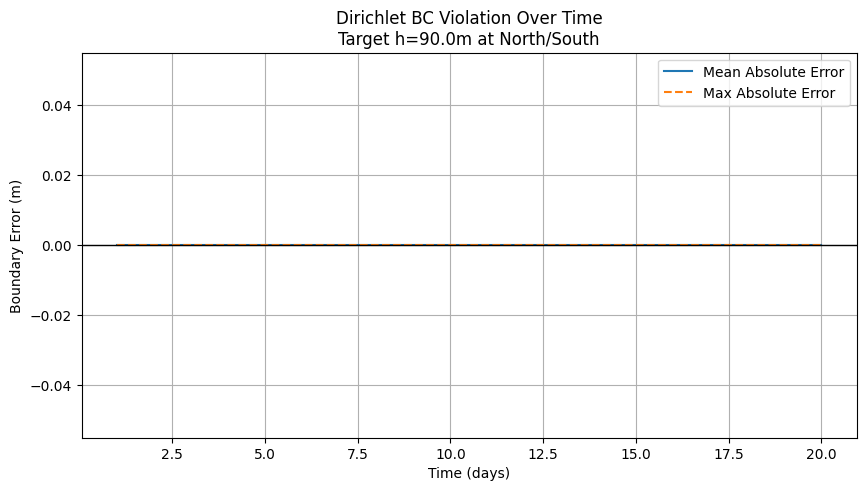

In [ ]:
# ============================================================================
# Figure 8: Dirichlet Boundary Condition Error
# ============================================================================
# Evaluates consistency with prescribed head h = 90.0 at North/South boundaries

model.eval()

h0 = 90.0  # Prescribed CHD head (North & South only)

print("=" * 80)
print("FIGURE 8: DIRICHLET BOUNDARY CONDITION CONSISTENCY")
print("=" * 80)
print("Evaluating ONLY prescribed boundaries (North & South)")
print("Metric: ε_BC = |h_pred - h_BC|,  h_BC = 90 m")
print("East/West excluded (no-flow boundaries)")
print("-" * 80)

# Dependencies check
if 'xy_grid_val' not in globals():
    print("⚠️ 'xy_grid_val' missing. Please run the 'PDE Residual Evaluation' cell first.")
else:
    # Use the same dense temporal sequence as Mass Balance to show stability
    # or just use the display times? Let's use the dense sequence for robustness stats.
    if 't_seq' not in globals():
        t_seq = np.linspace(1.0, 20.0, 50)

    boundary_errors_all = []
    mae_over_time = []
    max_over_time = []

    # Identify Boundary Indices in the Grid
    # Grid construction was: meshgrid(x, y), then flatten.
    # Rows depend on how meshgrid was unwrapped.
    # Usually: grid_x varies fast, grid_y varies slow? Or vice versa?
    # Let's verify:
    # xy_grid_val constructed as: np.vstack([grid_x.ravel(), grid_y.ravel()]).T
    # If grid_x, grid_y = np.meshgrid(x, y)
    # y is constant along valid x row?
    # North Boundary: y = y_max (500) -> Last "row" of grid if reshaped (ny, nx)
    # South Boundary: y = y_min (-500)-> First "row" of grid if reshaped (ny, nx)

    # Let's test precisely using coordinates
    y_coords = xy_grid_val[:, 1]
    y_max = np.max(y_coords)
    y_min = np.min(y_coords)

    # Indices where y is approx y_max or y_min
    north_mask = np.isclose(y_coords, y_max)
    south_mask = np.isclose(y_coords, y_min)

    idx_north = np.where(north_mask)[0]
    idx_south = np.where(south_mask)[0]

    print(f"Found {len(idx_north)} points on North boundary (y={y_max})")
    print(f"Found {len(idx_south)} points on South boundary (y={y_min})")

    with torch.no_grad():
        for t_val in t_seq:
            # Predict only on boundary points?
            # Or predict full grid and slice? predicting full grid is easier for batching
            t_vec = np.full((xy_grid_val.shape[0], 1), t_val)
            xyt_input = np.hstack([xy_grid_val, t_vec])
            xyt_tensor = torch.from_numpy(xyt_input).float().to(device)

            h_pred = model(xyt_tensor).cpu().numpy().flatten()

            # Extract Boundary Heads
            h_north = h_pred[idx_north]
            h_south = h_pred[idx_south]

            # Known BCs
            bc_north = np.full_like(h_north, h0)
            bc_south = np.full_like(h_south, h0)

            # Errors
            err_north = np.abs(h_north - bc_north)
            err_south = np.abs(h_south - bc_south)

            # Combine
            err_total = np.concatenate([err_north, err_south])

            boundary_errors_all.extend(err_total)
            mae_over_time.append(np.mean(err_total))
            max_over_time.append(np.max(err_total))

    boundary_errors_all = np.array(boundary_errors_all)
    mae_over_time = np.array(mae_over_time)
    max_over_time = np.array(max_over_time)

    print("\nBOUNDARY ERROR SUMMARY (Over full time sequence):")
    print(f"Mean MAE:  {mae_over_time.mean():.4f} m")
    print(f"Max Error: {max_over_time.max():.4f} m (Worst case)")
    print(f"99th pct:  {np.percentile(boundary_errors_all, 99):.4f} m")
    print("=" * 80)

    # Plotting
    fig, ax = plt.figure(figsize=(10, 5)), plt.gca()
    plt.plot(t_seq, mae_over_time, label='Mean Absolute Error')
    plt.plot(t_seq, max_over_time, label='Max Absolute Error', linestyle='--')
    plt.axhline(0, color='k', lw=1)

    plt.xlabel('Time (days)')
    plt.ylabel('Boundary Error (m)')
    plt.title(f'Dirichlet BC Violation Over Time\nTarget h={h0}m at North/South')
    plt.legend()
    plt.grid(True)
    plt.show()


Mass balance grid: 300x300, dx=3.34m, dy=3.34m
Evaluating Mass Balance over 60 timesteps...

MASS BALANCE SUMMARY
Mean Abs Residual:       3944.6 m³/day
Max  Abs Residual:      18310.9 m³/day
Mean Rel Error:            9.86 %  (of |Q_well|=40000)
Boundary inflow (t=1):      4081.4 m³/day
Boundary inflow (t=30):    37115.6 m³/day
Storage rate    (t=1):    -17607.7 m³/day
Storage rate    (t=30):     3293.4 m³/day


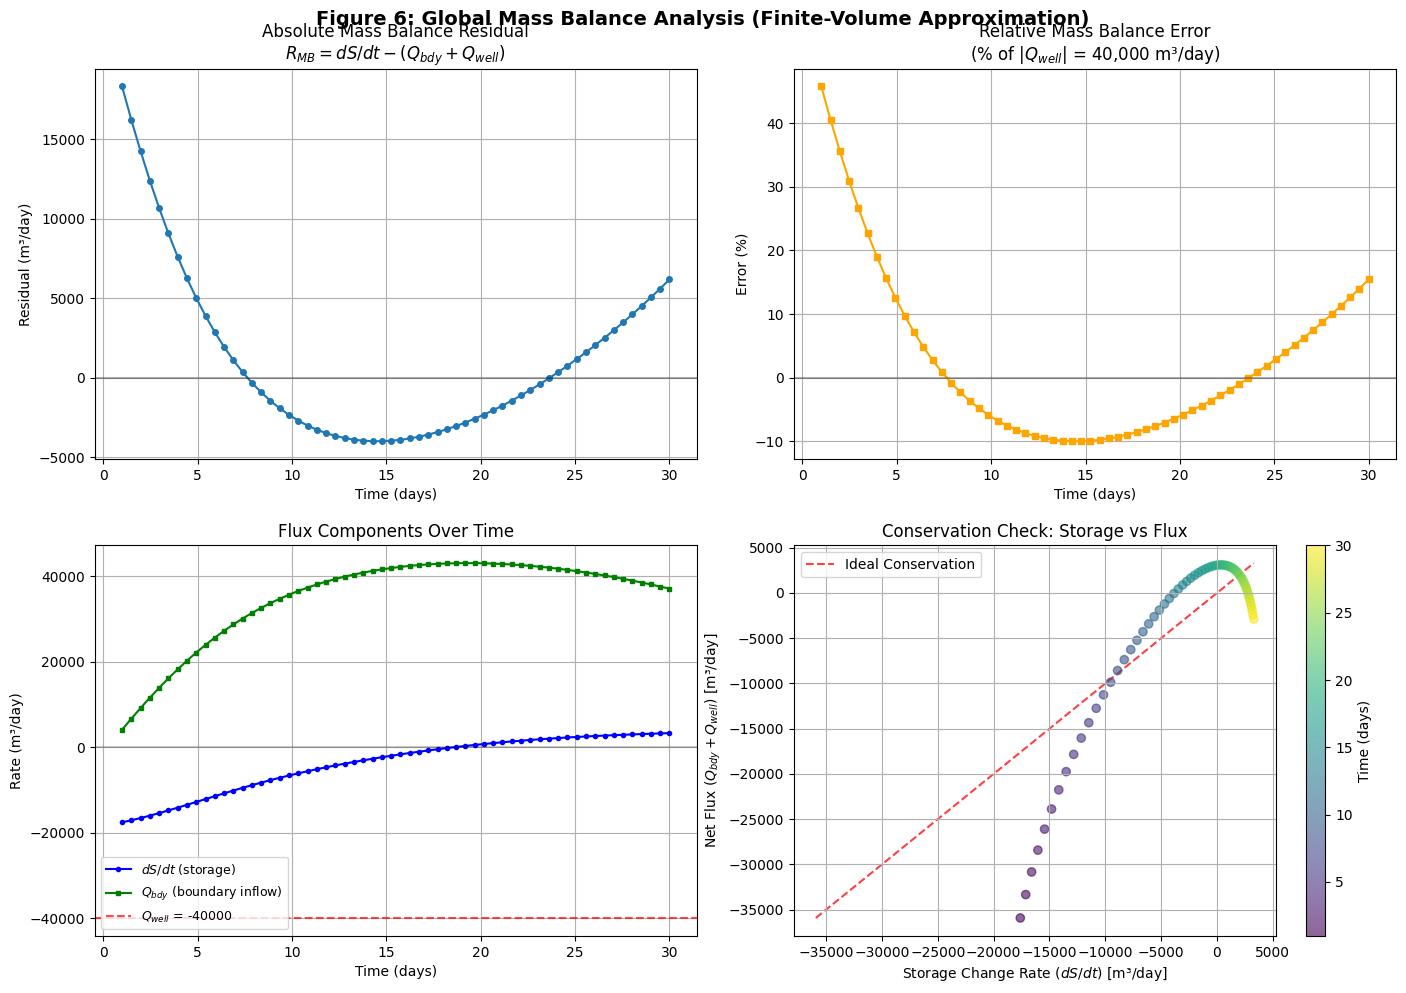

In [ ]:
# ============================================================================
# Figure 6: Mass Balance Error (Finite-Volume, MODFLOW-Consistent Diagnostic)
# ============================================================================
# Analyzes global mass conservation: dS/dt = Q_boundary + Q_wells
# Uses gradient-based Darcy flux at boundaries (node-centered grid)
# ============================================================================

model.eval()

# -------------------------
# 1. Setup Parameters & Grid (self-contained)
# -------------------------
K     = 33.33        # m/day
Sy    = 0.10         # Specific Yield
h0    = 90.0         # CHD boundary head (North/South)
Q_well_total = -40000.0  # m³/day (negative = pumping)

# Grid — must match previous cells or be self-contained
nx_mb, ny_mb = 300, 300
x_mb = np.linspace(-500, 500, nx_mb)
y_mb = np.linspace(-500, 500, ny_mb)
dx_mb = x_mb[1] - x_mb[0]
dy_mb = y_mb[1] - y_mb[0]
cell_area_mb = dx_mb * dy_mb

grid_x_mb, grid_y_mb = np.meshgrid(x_mb, y_mb)
xy_grid_mb = np.vstack([grid_x_mb.ravel(), grid_y_mb.ravel()]).T  # (N, 2)

print(f"Mass balance grid: {nx_mb}x{ny_mb}, dx={dx_mb:.2f}m, dy={dy_mb:.2f}m")

# -------------------------
# Boundary Flux via Darcy's Law (gradient-based)
# -------------------------
def boundary_flux_gradient(head_grid):
    """
    Compute net boundary inflow using Darcy's law + head gradient.
    head_grid: (ny, nx) array

    South boundary = row 0  (y = y_min = -500)
    North boundary = row -1 (y = y_max = +500)

    Returns total inflow rate (m³/day), positive = into domain.
    """
    # South boundary: inward flux (outward normal is -y)
    h_bdy_s  = head_grid[0, :]    # = 90 by hard constraint
    h_int_s  = head_grid[1, :]    # first interior row
    h_avg_s  = 0.5 * (h_bdy_s + h_int_s)
    Q_south  = np.sum(K * h_avg_s * (h_bdy_s - h_int_s) / dy_mb * dx_mb)

    # North boundary: inward flux (outward normal is +y)
    h_bdy_n  = head_grid[-1, :]   # = 90 by hard constraint
    h_int_n  = head_grid[-2, :]   # first interior row
    h_avg_n  = 0.5 * (h_bdy_n + h_int_n)
    Q_north  = np.sum(K * h_avg_n * (h_bdy_n - h_int_n) / dy_mb * dx_mb)

    return Q_south + Q_north, Q_south, Q_north

# -------------------------
# 2. Evaluate Over Time
# -------------------------
t_seq = np.linspace(1.0, 30.0, 60)

mb_errors, storage_terms, boundary_terms, forcing_terms, timesteps_plot = [], [], [], [], []

print(f"Evaluating Mass Balance over {len(t_seq)} timesteps...")

with torch.no_grad():
    for t_val in t_seq:
        # A. Predict h(t) on the mass-balance grid
        t_vec = np.full((xy_grid_mb.shape[0], 1), t_val)
        xyt_input = np.hstack([xy_grid_mb, t_vec])
        xyt_tensor = torch.from_numpy(xyt_input).float().to(device)
        h_t = model(xyt_tensor).cpu().numpy().reshape(ny_mb, nx_mb)

        # B. Predict h(t - eps) for dS/dt
        dt_deriv = 0.01
        t_prev_val = t_val - dt_deriv
        t_vec_prev = np.full((xy_grid_mb.shape[0], 1), t_prev_val)
        xyt_input_prev = np.hstack([xy_grid_mb, t_vec_prev])
        xyt_tensor_prev = torch.from_numpy(xyt_input_prev).float().to(device)
        h_prev = model(xyt_tensor_prev).cpu().numpy().reshape(ny_mb, nx_mb)

        # C. Storage change rate: sum(Sy * dh/dt * cell_area)
        dh_dt = (h_t - h_prev) / dt_deriv
        Rate_Storage = np.sum(Sy * dh_dt) * cell_area_mb

        # D. Boundary flux (gradient-based Darcy)
        Rate_Boundary, _, _ = boundary_flux_gradient(h_t)

        # E. Well flux
        Rate_Wells = Q_well_total

        # F. Residual: dS/dt should equal (boundary inflow + well extraction)
        eps_MB = Rate_Storage - (Rate_Boundary + Rate_Wells)

        mb_errors.append(eps_MB)
        storage_terms.append(Rate_Storage)
        boundary_terms.append(Rate_Boundary)
        forcing_terms.append(Rate_Boundary + Rate_Wells)
        timesteps_plot.append(t_val)

mb_errors = np.array(mb_errors)
storage_terms = np.array(storage_terms)
boundary_terms = np.array(boundary_terms)
forcing_terms = np.array(forcing_terms)
timesteps_plot = np.array(timesteps_plot)

# Relative Error — normalized by |Q_well| (stable reference scale)
# NOTE: normalizing by |net forcing| gives misleading % near steady state
# because net forcing → 0 as boundary inflow balances well pumping.
rel_MB = 100.0 * mb_errors / np.abs(Q_well_total)

print(f"\n{'='*60}")
print(f"MASS BALANCE SUMMARY")
print(f"{'='*60}")
print(f"Mean Abs Residual:   {np.mean(np.abs(mb_errors)):>10.1f} m³/day")
print(f"Max  Abs Residual:   {np.max(np.abs(mb_errors)):>10.1f} m³/day")
print(f"Mean Rel Error:      {np.mean(np.abs(rel_MB)):>10.2f} %  (of |Q_well|={np.abs(Q_well_total):.0f})")
print(f"{'='*60}")
print(f"Boundary inflow (t=1):  {boundary_terms[0]:>10.1f} m³/day")
print(f"Boundary inflow (t=30): {boundary_terms[-1]:>10.1f} m³/day")
print(f"Storage rate    (t=1):  {storage_terms[0]:>10.1f} m³/day")
print(f"Storage rate    (t=30): {storage_terms[-1]:>10.1f} m³/day")
print(f"{'='*60}")

# -------------------------
# 3. Plot
# -------------------------
fig = plt.figure(figsize=(14, 10))

ax1 = plt.subplot(2, 2, 1)
ax1.plot(timesteps_plot, mb_errors, 'o-', markersize=4, label='Residual')
ax1.axhline(0, ls='-', color='k', alpha=0.3)
ax1.set_title("Absolute Mass Balance Residual\n$R_{MB} = dS/dt - (Q_{bdy} + Q_{well})$")
ax1.set_ylabel("Residual (m³/day)")
ax1.set_xlabel("Time (days)")
ax1.grid(True)

ax2 = plt.subplot(2, 2, 2)
ax2.plot(timesteps_plot, rel_MB, 's-', markersize=4, color='orange')
ax2.axhline(0, ls='-', color='k', alpha=0.3)
ax2.set_title("Relative Mass Balance Error\n(% of $|Q_{well}|$ = 40,000 m³/day)")
ax2.set_ylabel("Error (%)")
ax2.set_xlabel("Time (days)")
ax2.grid(True)

ax3 = plt.subplot(2, 2, 3)
# Plot individual flux components over time for physical insight
ax3.plot(timesteps_plot, storage_terms, 'b-o', markersize=3, label='$dS/dt$ (storage)')
ax3.plot(timesteps_plot, boundary_terms, 'g-s', markersize=3, label='$Q_{bdy}$ (boundary inflow)')
ax3.axhline(Q_well_total, ls='--', color='r', alpha=0.7, label=f'$Q_{{well}}$ = {Q_well_total:.0f}')
ax3.axhline(0, ls='-', color='k', alpha=0.2)
ax3.set_xlabel("Time (days)")
ax3.set_ylabel("Rate (m³/day)")
ax3.set_title("Flux Components Over Time")
ax3.legend(fontsize=9)
ax3.grid(True)

ax4 = plt.subplot(2, 2, 4)
ax4.scatter(storage_terms, forcing_terms, alpha=0.6, c=timesteps_plot, cmap='viridis')
lims = [
    min(np.min(storage_terms), np.min(forcing_terms)),
    max(np.max(storage_terms), np.max(forcing_terms)),
]
ax4.plot(lims, lims, 'r--', alpha=0.75, zorder=0, label='Ideal Conservation')
ax4.set_xlabel("Storage Change Rate ($dS/dt$) [m³/day]")
ax4.set_ylabel("Net Flux ($Q_{bdy} + Q_{well}$) [m³/day]")
ax4.set_title("Conservation Check: Storage vs Flux")
cb = plt.colorbar(ax4.collections[0], ax=ax4, label='Time (days)')
ax4.legend(loc='upper left')
ax4.grid(True)

plt.suptitle(
    "Figure 6: Global Mass Balance Analysis (Finite-Volume Approximation)",
    fontweight="bold", fontsize=14
)
plt.tight_layout(pad=0.5, w_pad=0.5, h_pad=1.5)
plt.show()

## 10. Natural Language Query Interface
Type a pumping instruction in plain English — the LLM parses it, the PINN answers instantly.

In [12]:
!pip install -q langchain langchain-google-genai langgraph
print('LLM dependencies ready.')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.1/515.1 kB 48.9 MB/s eta 0:00:00
LLM dependencies ready.


In [13]:
from google.colab import userdata
import os

# Store your key in Colab Secrets (key icon, left sidebar) as GEMINI_API_KEY
GEMINI_API_KEY = userdata.get('Gemini')
os.environ['GOOGLE_API_KEY'] = GEMINI_API_KEY
print('Gemini API key set.')


Gemini API key set.


In [14]:
import sys, os
sys.path.insert(0, DRIVE_CODE)
from llm_interface_wrapper import llm_interface
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import HumanMessage
import numpy as np, torch, matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import textwrap

Q_BASELINE = -40000.0
Q_MIN      = -50000.0
Q_MAX      = -25000.0
H0         = 90.0
_TAU       = 1.0
T_END      = 30.0
NX, NY     = 100, 100
WELL_XY    = (201.67, -98.33)

def _norm_Q(Q):
    return 2.0 * (Q - Q_MIN) / (Q_MAX - Q_MIN) - 1.0

def _infer_field(Q, t=T_END):
    xl = np.linspace(-500, 500, NX)
    yl = np.linspace(-500, 500, NY)
    XX, YY = np.meshgrid(xl, yl)
    xy = np.column_stack([XX.ravel(), YY.ravel()])
    N  = xy.shape[0]
    Qn = _norm_Q(Q)
    tau_t = torch.from_numpy(np.hstack([xy, np.full((N,1), _TAU)]).astype(np.float32)).to(device)
    xyt_t = torch.from_numpy(np.hstack([xy, np.full((N,1), t  )]).astype(np.float32)).to(device)
    with torch.no_grad():
        h = net2(xyt_t, Qn, net1(tau_t, Qn))
    return XX, YY, h.cpu().numpy().reshape(NY, NX)

def _infer_ts(Q, x, y, times):
    Qn, out = _norm_Q(Q), []
    for t in times:
        if t <= _TAU:
            xyt = torch.tensor([[x, y, t]], dtype=torch.float32, device=device)
            with torch.no_grad(): h = net1(xyt, Qn)
        else:
            tau_t = torch.tensor([[x, y, _TAU]], dtype=torch.float32, device=device)
            xyt   = torch.tensor([[x, y, t   ]], dtype=torch.float32, device=device)
            with torch.no_grad(): h = net2(xyt, Qn, net1(tau_t, Qn))
        out.append(float(h.cpu()))
    return H0 - np.array(out)

def _llm_explain(instruction, pct, Q_new, dd_base, dd_scen, delta_dd, area_b, area_s, T_END):
    change_word = 'deeper' if pct > 0 else 'shallower'
    area_change = area_s - area_b
    prompt = (
        'You are an agricultural water management advisor explaining groundwater model results to a farmer.\n\n'
        f'The farmer asked: "{instruction}"\n\n'
        'The groundwater model computed the following results:\n'
        f'- Pumping change: {pct*100:+.1f}% (new rate: {Q_new:,.0f} m3/day vs baseline {Q_BASELINE:,.0f} m3/day)\n'
        f'- Baseline max drawdown near the well: {dd_base:.2f} m\n'
        f'- Scenario max drawdown near the well: {dd_scen:.2f} m ({delta_dd:+.2f} m {change_word})\n'
        f'- Area where water table drops more than 5 m: {area_b:.2f} km2 (baseline) -> {area_s:.2f} km2 (scenario) ({area_change:+.2f} km2)\n'
        f'- Time horizon: {T_END:.0f} days\n\n'
        'Write exactly 3-4 sentences in plain English for a farmer. No jargon, no equations, no intro phrase.\n'
        'Start your response directly with the first sentence of the explanation.\n'
        'Cover: (1) what pumping more/less means for their water supply, '
        '(2) how the water table will change near their well, '
        '(3) a practical action or warning they should act on.\n'
        'Use the numbers only to inform the message — do not list them verbatim.'
    )
    llm = ChatGoogleGenerativeAI(
        model='gemini-2.5-flash',
        google_api_key=GEMINI_API_KEY,
        temperature=0.3,
        max_output_tokens=8192,   # thinking tokens consumed the old 512 budget
    )
    response = llm.invoke([HumanMessage(content=prompt)])
    return response.content.strip()

def pinn_query(instruction):
    SEP = '=' * 65
    print(SEP)
    print(f'  Query: "{instruction}"')
    print(SEP)

    resp = llm_interface(
        input_json_file_path=os.path.join(DRIVE_CODE, 'input.json'),
        user_instruction=instruction,
        llm_name='gemini-2.5-flash',
        api_key=GEMINI_API_KEY,
        write_output=False,
    )
    if not resp['is_valid']:
        print('[FAIL]', resp['invalid_explanation']); return

    pct_raw = None
    for zid, payload in resp['result'].get('zone_updates', {}).items():
        v = payload.get('updates', {}).get('pumping_change_percentage')
        if v is not None:
            pct_raw = float(v); break
    if pct_raw is None:
        print('[FAIL] pumping_change_percentage not found.', resp['result']); return

    pct   = pct_raw / 100.0 if abs(pct_raw) > 3 else pct_raw
    Q_new = Q_BASELINE * (1.0 + pct)
    print(f'  Parsed : {pct*100:+.1f}%  ->  Q = {Q_new:,.0f} m3/day', end='  ')
    print('[in range]' if Q_MIN <= Q_new <= Q_MAX else '[OUTSIDE training range]')

    XX, YY, h_base = _infer_field(Q_BASELINE)
    XX, YY, h_scen = _infer_field(Q_new)
    dh = h_scen - h_base

    t_s = np.concatenate([np.linspace(0.05, _TAU, 12), np.linspace(_TAU, T_END, 50)[1:]])
    dd_base_ts = _infer_ts(Q_BASELINE, *WELL_XY, t_s)
    dd_scen_ts = _infer_ts(Q_new,      *WELL_XY, t_s)

    dd_base  = H0 - float(np.min(h_base))
    dd_scen  = H0 - float(np.min(h_scen))
    delta_dd = dd_scen - dd_base
    max_dh   = float(np.max(np.abs(dh)))
    mean_dh  = float(np.mean(dh))
    ca       = (1000/NX)*(1000/NY)/1e6
    area_b   = float(np.sum((H0-h_base)>5.0))*ca
    area_s   = float(np.sum((H0-h_scen)>5.0))*ca
    deeper   = 'deeper' if pct > 0 else 'shallower'

    print(f'\n  Max drawdown  baseline : {dd_base:.2f} m')
    print(f'  Max drawdown  scenario : {dd_scen:.2f} m  ({delta_dd:+.2f} m, {deeper} near well)')
    print(f'  Max |Dh| anywhere      : {max_dh:.3f} m')
    print(f'  Area drawdown > 5 m    : {area_b:.2f} km2 (baseline)  ->  {area_s:.2f} km2 (scenario)  ({area_s-area_b:+.2f} km2)')

    # -- LLM farmer explanation -----------------------------------------
    try:
        explanation = _llm_explain(instruction, pct, Q_new, dd_base, dd_scen, delta_dd, area_b, area_s, T_END)
        print('\n' + SEP)
        print('  WHAT THIS MEANS FOR YOU:')
        print(SEP)
        for line in textwrap.wrap(explanation, width=63):
            print('  ' + line)
        print(SEP + '\n')
    except Exception as e:
        print(f'\n  [LLM unavailable: {e}]\n')

    vmax   = max(max_dh, 0.01)
    levels = [85, 86, 87, 88, 89]
    fig = plt.figure(figsize=(18, 11))
    gs  = GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

    axA = fig.add_subplot(gs[0,0])
    cfA = axA.contourf(XX, YY, h_base, 20, cmap='Blues_r')
    axA.contour(XX, YY, h_base, levels=levels, colors='k', linewidths=0.6, linestyles='--', alpha=0.6)
    axA.plot(*WELL_XY, 'r*', ms=11, zorder=5)
    plt.colorbar(cfA, ax=axA, label='h (m)')
    axA.set_title(f'(A) Baseline head (t={T_END:.0f} d)\nQ={Q_BASELINE:,.0f} m3/day   max drawdown={dd_base:.2f} m', fontsize=10)
    axA.set_xlabel('x (m)'); axA.set_ylabel('y (m)'); axA.set_aspect('equal')

    axB = fig.add_subplot(gs[0,1])
    cfB = axB.contourf(XX, YY, h_scen, 20, cmap='Blues_r')
    axB.contour(XX, YY, h_scen, levels=levels, colors='k', linewidths=0.6, linestyles='--', alpha=0.6)
    axB.plot(*WELL_XY, 'r*', ms=11, zorder=5)
    plt.colorbar(cfB, ax=axB, label='h (m)')
    axB.set_title(f'(B) Scenario head (t={T_END:.0f} d)\nQ={Q_new:,.0f} m3/day ({pct*100:+.1f}%)   max drawdown={dd_scen:.2f} m', fontsize=10)
    axB.set_xlabel('x (m)'); axB.set_aspect('equal')

    axC = fig.add_subplot(gs[0,2])
    cfC = axC.contourf(XX, YY, dh, 20, cmap='RdBu_r', vmin=-vmax, vmax=vmax)
    axC.plot(*WELL_XY, 'k*', ms=11, zorder=5)
    plt.colorbar(cfC, ax=axC, label='Dh (m)')
    axC.set_title(f'(C) Head change Dh\nmax|Dh|={max_dh:.3f} m   mean Dh={mean_dh:+.4f} m', fontsize=10)
    axC.set_xlabel('x (m)'); axC.set_aspect('equal')

    axD = fig.add_subplot(gs[1,:])
    axD.plot(t_s, dd_base_ts, 'b-',  lw=2.5, label=f'Baseline  Q={Q_BASELINE:,.0f} m3/day')
    axD.plot(t_s, dd_scen_ts, 'r--', lw=2.5, label=f'Scenario  Q={Q_new:,.0f} m3/day ({pct*100:+.1f}%)')
    axD.fill_between(t_s, dd_base_ts, dd_scen_ts, alpha=0.12, color='red' if pct>0 else 'blue')
    axD.axvline(_TAU, color='gray', lw=1.5, ls=':', label=f'Stage boundary t={_TAU:.0f} d')
    axD.axhline(5.0,  color='purple', lw=1, ls='--', alpha=0.6, label='5 m drawdown threshold')
    axD.set_xlabel('Time (days)', fontsize=11)
    axD.set_ylabel('Drawdown at well (m)', fontsize=11)
    axD.set_title(f'(D) Drawdown time-series at well ({WELL_XY[0]:.0f}, {WELL_XY[1]:.0f}) m', fontsize=10)
    axD.legend(fontsize=10, loc='lower right')
    axD.grid(alpha=0.3)
    axD.invert_yaxis()

    fig.suptitle(
        f'GW-PINN Response  |  "{instruction}"\n'
        'Parameterized model — instant inference, no retraining',
        fontsize=12, fontweight='bold', y=1.02
    )
    plt.subplots_adjust(top=0.88, hspace=0.45, wspace=0.38)
    plt.show()
    print(SEP)

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

instruction_box = widgets.Text(
    value='increase pumping by 15 percent in Blue River Basin',
    placeholder='e.g. reduce pumping by 25 percent',
    description='Query:',
    layout=widgets.Layout(width='650px')
)

run_button = widgets.Button(
    description='Run PINN Query',
    button_style='primary',
    icon='play',
    layout=widgets.Layout(width='160px')
)

out = widgets.Output()

def on_click(b):
    with out:
        clear_output(wait=True)
        pinn_query(instruction_box.value)

run_button.on_click(on_click)

print("Type your pumping instruction and click Run:")
display(widgets.HBox([instruction_box, run_button]))
display(out)

Type your pumping instruction and click Run:


Output()

In [ ]:
# pinn_query("reduce pumping by 25 percent in Blue River Basin")

In [15]:
# ============================================================
# PINN BENCHMARK  —  inference time per scenario
# ============================================================
import time, numpy as np, torch

NX_B, NY_B = 100, 100
N_RUNS      = 50   # repeat for stable mean

xl = np.linspace(-500, 500, NX_B)
yl = np.linspace(-500, 500, NY_B)
XX_b, YY_b = np.meshgrid(xl, yl)
xy_b = np.column_stack([XX_b.ravel(), YY_b.ravel()])
N_pts = xy_b.shape[0]

def _one_inference(Q):
    Qn = _norm_Q(Q)
    tau_t = torch.from_numpy(
        np.hstack([xy_b, np.full((N_pts,1), _TAU)]).astype(np.float32)).to(device)
    xyt_t = torch.from_numpy(
        np.hstack([xy_b, np.full((N_pts,1), T_END)]).astype(np.float32)).to(device)
    with torch.no_grad():
        h = net2(xyt_t, Qn, net1(tau_t, Qn))
    return h.cpu().numpy().reshape(NY_B, NX_B)

# warm-up pass
_ = _one_inference(Q_BASELINE)
if torch.cuda.is_available():
    torch.cuda.synchronize()

# timed runs
times_ms = []
for i in range(N_RUNS):
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = _one_inference(Q_BASELINE)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    times_ms.append((time.perf_counter() - t0) * 1000)

times_ms = np.array(times_ms)
SEP = '=' * 60

if torch.cuda.is_available():
    hw = 'GPU (' + torch.cuda.get_device_name(0) + ')'
else:
    hw = 'CPU'

print(SEP)
print('  PINN SURROGATE -- Inference Benchmark')
print(SEP)
print(f'  Grid            : {NX_B}x{NY_B} = {N_pts:,} query points')
print(f'  Repetitions     : {N_RUNS}')
print(f'  Mean            : {times_ms.mean():.2f} ms')
print(f'  Median          : {np.median(times_ms):.2f} ms')
print(f'  Min / Max       : {times_ms.min():.2f} / {times_ms.max():.2f} ms')
print(f'  Hardware        : {hw}')
print(SEP)
print()
print('  MODFLOW comparison (300x300 grid, 33 stress periods, PCG solver):')
print('  --> Run  python benchmark_modflow.py  locally and record solver time.')
print()
mean_ms = times_ms.mean()
for mf_s in [10, 30, 60, 120]:
    speedup = (mf_s * 1000) / mean_ms
    print(f'  If MODFLOW = {mf_s:>3d}s  =>  PINN is ~{speedup:,.0f}x faster')
print(SEP)


  PINN SURROGATE -- Inference Benchmark
  Grid            : 100x100 = 10,000 query points
  Repetitions     : 50
  Mean            : 3.22 ms
  Median          : 3.17 ms
  Min / Max       : 3.10 / 3.93 ms
  Hardware        : GPU (Tesla T4)

  MODFLOW comparison (300x300 grid, 33 stress periods, PCG solver):
  --> Run  python benchmark_modflow.py  locally and record solver time.

  If MODFLOW =  10s  =>  PINN is ~3,101x faster
  If MODFLOW =  30s  =>  PINN is ~9,304x faster
  If MODFLOW =  60s  =>  PINN is ~18,608x faster
  If MODFLOW = 120s  =>  PINN is ~37,216x faster
